# Pre-Test Diabetes Risk Prioritisation using Non-Glycemic NHANES Indicators

This notebook reviews the reproducible outputs created by `python scripts/run_nhanes_feasibility.py`. It is a feasibility analysis, not a diagnostic model.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
TABLES = ROOT / 'reports' / 'nhanes_feasibility' / 'tables'
FIGURES = ROOT / 'reports' / 'nhanes_feasibility' / 'figures'


## Data availability and target definition

,component,filename,status,source_url
0,demographics,DEMO_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
1,diabetes_questionnaire,DIQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
2,body_measures,BMX_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
3,blood_pressure_exam,BPX_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
4,blood_pressure_questionnaire,BPQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
5,medical_conditions,MCQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
6,physical_activity,PAQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
7,smoking,SMQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
8,alcohol,ALQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...
9,diet,DBQ_I.XPT,available,https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2...


,label_source,nhanes_variable,available,class_1_rule,class_2_rule
0,self-reported doctor-diagnosed/borderline diab...,DIQ010,True,DIQ010 == 3 (borderline),DIQ010 == 1 (doctor diagnosed)
1,self-reported prediabetes,DIQ160,True,DIQ160 == 1 (ever told prediabetes),not used for class 2
2,HbA1c,LBXGH,True,5.7 <= LBXGH <= 6.4,LBXGH >= 6.5
3,fasting plasma glucose,LBXGLU,True,100 <= LBXGLU <= 125 mg/dL,LBXGLU >= 126 mg/dL
4,2-hour OGTT glucose,LBXGLT,True,140 <= LBXGLT <= 199 mg/dL,LBXGLT >= 200 mg/dL


,class,count,class_name,percentage
0,0,2572,Normal / lower-risk,0.449729
1,1,2017,Diabetes-prone / prediabetes-risk,0.352684
2,2,1130,Diabetic / diabetes-range,0.197587


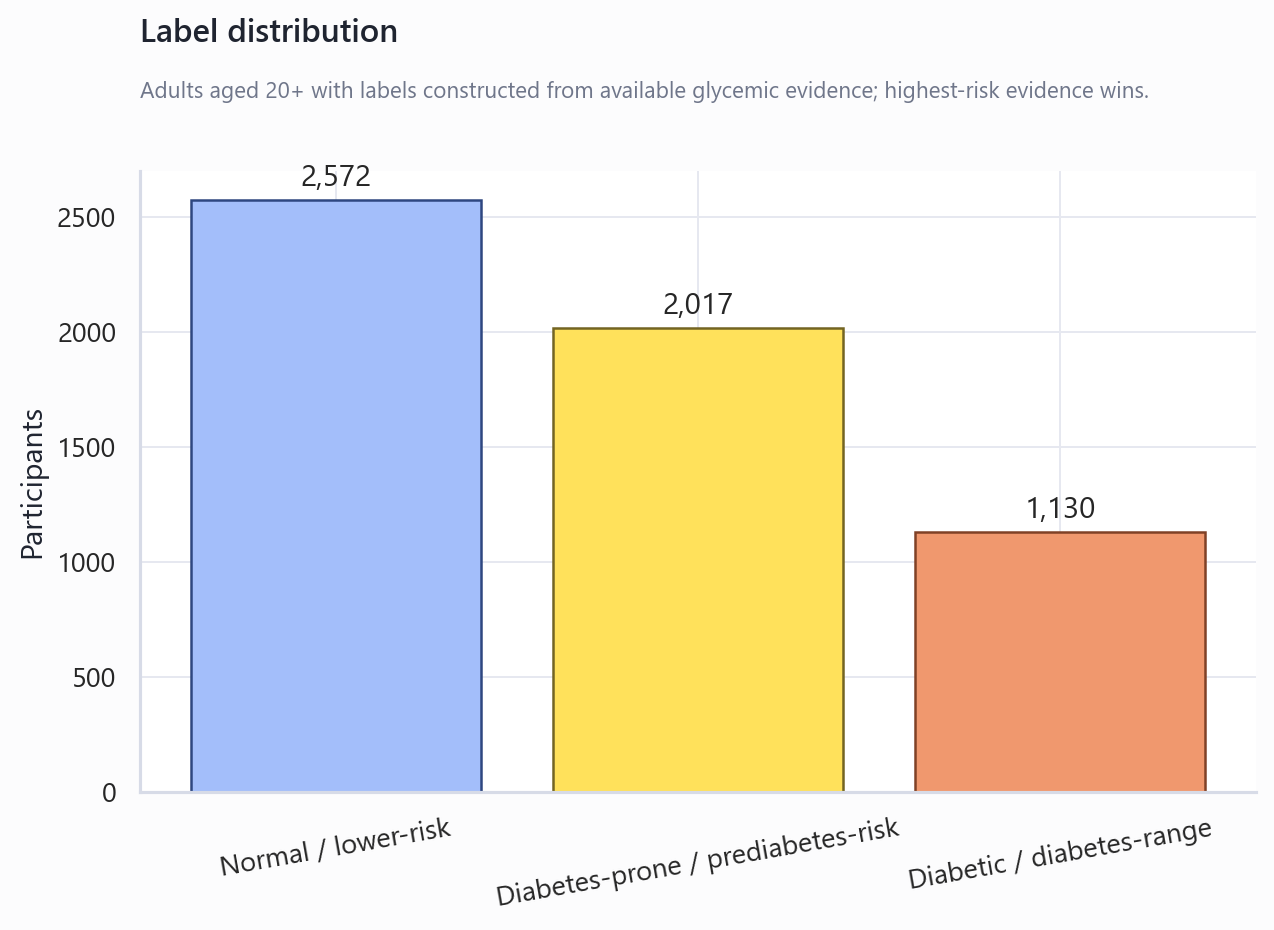

In [2]:
display(pd.read_csv(TABLES / 'dataset_files_used.csv'))
display(pd.read_csv(TABLES / 'label_variable_dictionary.csv'))
display(pd.read_csv(TABLES / 'label_distribution.csv'))
display(Image(filename=str(FIGURES / 'label_distribution.png')))


## Missingness and Tier-1 feature coverage

In [3]:
missingness = pd.read_csv(TABLES / 'missingness_report.csv')
display(missingness.head(25))
display(pd.read_csv(TABLES / 'tier1_features_used.csv'))
display(pd.read_csv(TABLES / 'engineered_features_dictionary.csv'))


,variable,dtype,non_missing,missing,missing_pct,unique_non_missing
0,BMIHEAD,float64,0,9971,1.000000,0
1,MCQ230D,float64,0,9971,1.000000,0
2,MCQ240D,float64,0,9971,1.000000,0
3,MCQ240I,float64,0,9971,1.000000,0
4,MCQ240K,float64,0,9971,1.000000,0
5,MCQ240R,float64,0,9971,1.000000,0
6,MCQ240Y,float64,0,9971,1.000000,0
7,DIQ175X,float64,1,9970,0.999900,1
8,MCQ240DK,float64,1,9970,0.999900,1
9,MCQ240B,float64,2,9969,0.999799,2


,feature,source_group,type,non_missing,missing_pct
0,RIDAGEYR,demographics,numeric,5719,0.000000
1,RIAGENDR,demographics,categorical,5719,0.000000
2,RIDRETH3,demographics,categorical,5719,0.000000
3,DMDEDUC2,demographics,categorical,5719,0.000000
4,INDFMPIR,demographics,numeric,5082,0.111383
...,...,...,...,...,...
60,cholesterol_history_flag,engineered,numeric,5719,0.000000
61,cardiovascular_history_flag,engineered,numeric,5719,0.000000
62,cardiometabolic_history_count,engineered,numeric,5719,0.000000
63,low_income_access_risk_flag,engineered,numeric,5719,0.000000


,feature,formula,group
0,avg_systolic_bp,"row mean of BPXSY1, BPXSY2, BPXSY3, BPXSY4",blood_pressure
1,avg_diastolic_bp,"row mean of BPXDI1, BPXDI2, BPXDI3, BPXDI4",blood_pressure
2,pulse_pressure,avg_systolic_bp - avg_diastolic_bp,blood_pressure
3,mean_arterial_pressure,avg_diastolic_bp + pulse_pressure / 3,blood_pressure
4,bmi_category,"WHO-style BMI bands: <18.5, 18.5-24.9, 25-29.9...",anthropometric
5,waist_to_height_ratio,BMXWAIST / BMXHT,anthropometric
6,central_obesity_flag,waist >=102 cm for men or >=88 cm for women,anthropometric
7,age_band,"20-34, 35-44, 45-54, 55-64, 65+",demographics
8,bmi_x_age,BMXBMI * RIDAGEYR,anthropometric
9,bmi_x_waist,BMXBMI * BMXWAIST,anthropometric


## Held-out model comparison

,model,macro_f1,class_0_recall,class_1_recall,class_2_recall,high_risk_recall,high_risk_precision,high_risk_pr_auc,high_risk_roc_auc,high_risk_brier_score
0,XGBoost,0.549,0.635,0.409,0.671,0.793,0.726,0.812,0.788,0.191
1,Logistic Regression,0.546,0.641,0.399,0.668,0.785,0.728,0.807,0.785,0.194
2,Simple Rule Score,0.447,0.673,0.177,0.625,0.687,0.720,0.755,0.753,0.206


,model,class,class_name,recall
0,Logistic Regression,0,Normal / lower-risk,0.641
1,Logistic Regression,1,Diabetes-prone / prediabetes-risk,0.399
2,Logistic Regression,2,Diabetic / diabetes-range,0.668
3,XGBoost,0,Normal / lower-risk,0.635
4,XGBoost,1,Diabetes-prone / prediabetes-risk,0.409
5,XGBoost,2,Diabetic / diabetes-range,0.671
6,Simple Rule Score,0,Normal / lower-risk,0.673
7,Simple Rule Score,1,Diabetes-prone / prediabetes-risk,0.177
8,Simple Rule Score,2,Diabetic / diabetes-range,0.625


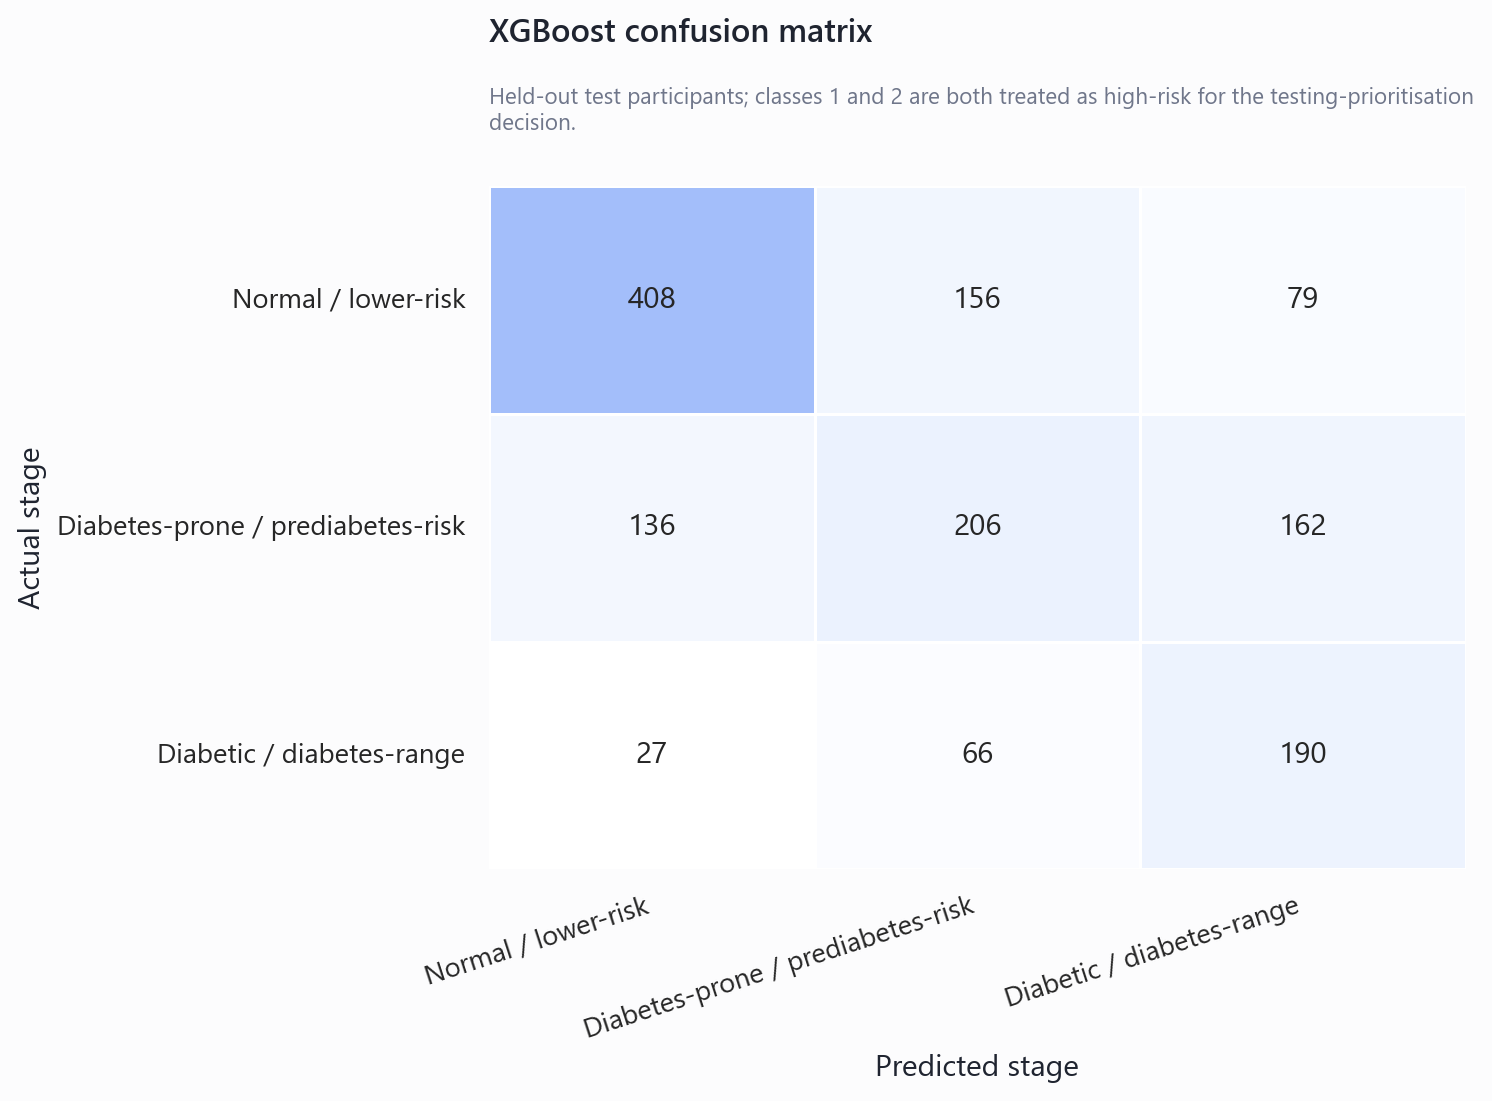

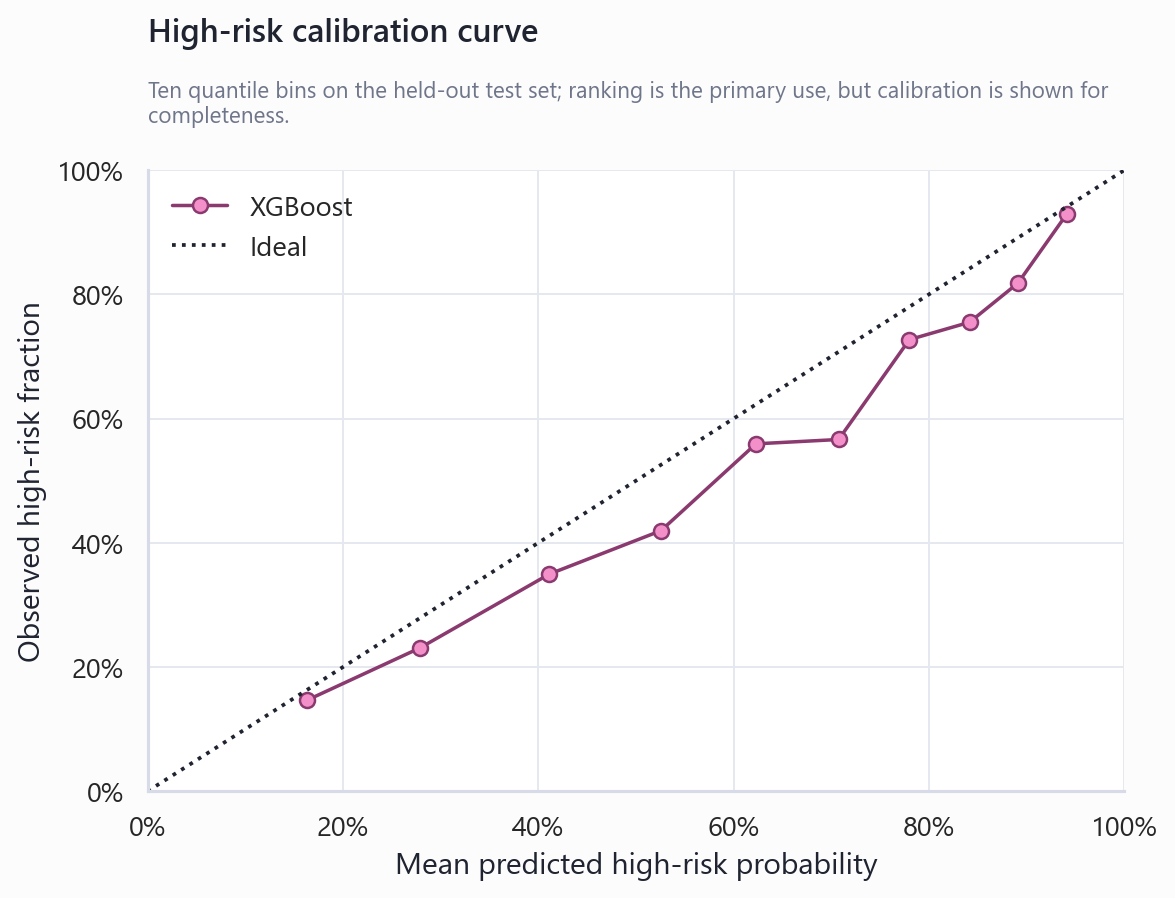

In [4]:
display(pd.read_csv(TABLES / 'model_comparison.csv').round(3))
display(pd.read_csv(TABLES / 'classwise_recall.csv').round(3))
display(Image(filename=str(FIGURES / 'confusion_matrix_xgboost.png')))
display(Image(filename=str(FIGURES / 'calibration_curve.png')))


## Confirmatory-testing prioritisation simulation

,model,testing_percentage,tested_n,testing_volume_reduction,high_risk_cases_captured,high_risk_capture_rate,diabetic_cases_captured,diabetic_capture_rate,diabetes_prone_cases_captured,diabetes_prone_capture_rate,number_needed_to_test,missed_high_risk_cases,precision_among_tested
0,XGBoost,0.1,143,0.9,133,0.169,82,0.290,51,0.101,1.075,654,0.930
1,XGBoost,0.2,286,0.8,250,0.318,137,0.484,113,0.224,1.144,537,0.874
2,XGBoost,0.3,429,0.7,358,0.455,176,0.622,182,0.361,1.198,429,0.834
3,XGBoost,0.4,572,0.6,462,0.587,216,0.763,246,0.488,1.238,325,0.808
4,XGBoost,0.5,715,0.5,543,0.690,244,0.862,299,0.593,1.317,244,0.759


,model,target_high_risk_recall,tested_n,minimum_testing_percentage,testing_volume_reduction,high_risk_cases_required
0,XGBoost,0.7,731,0.511,0.489,551
1,XGBoost,0.8,871,0.609,0.391,630
2,XGBoost,0.9,1077,0.753,0.247,709


,criterion,definition,observed,passed
0,A,Top 30% captures >=70% OR top 40% captures >=8...,top30=45.5%; top40=58.7%,False
1,B,"At 80% high-risk recall, testing volume is red...",testing=60.9%; reduction=39.1%,False
2,C,XGBoost exceeds rule score by >=0.03 PR-AUC an...,PR-AUC delta=+0.057; top30 delta=+2.2%; top40 ...,False


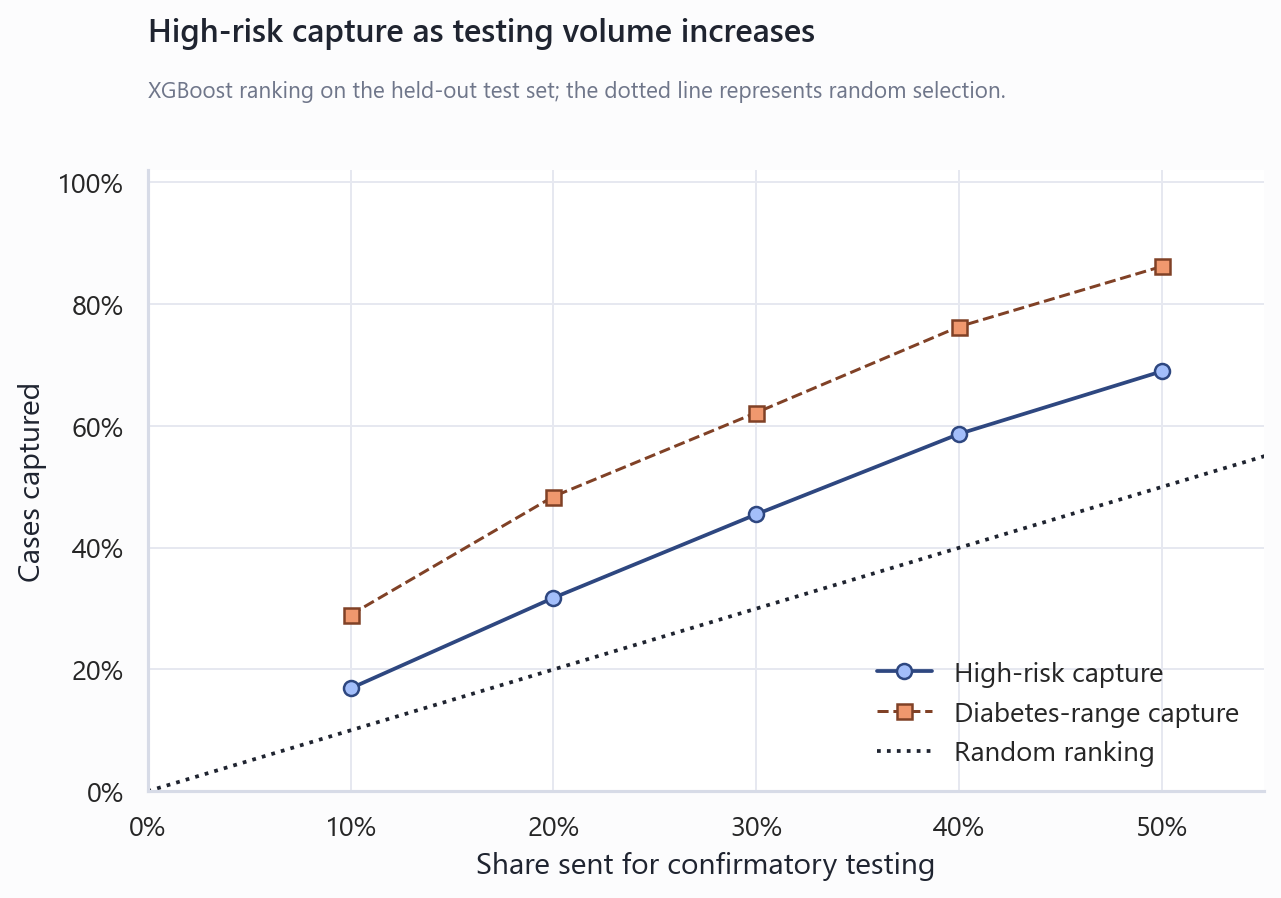

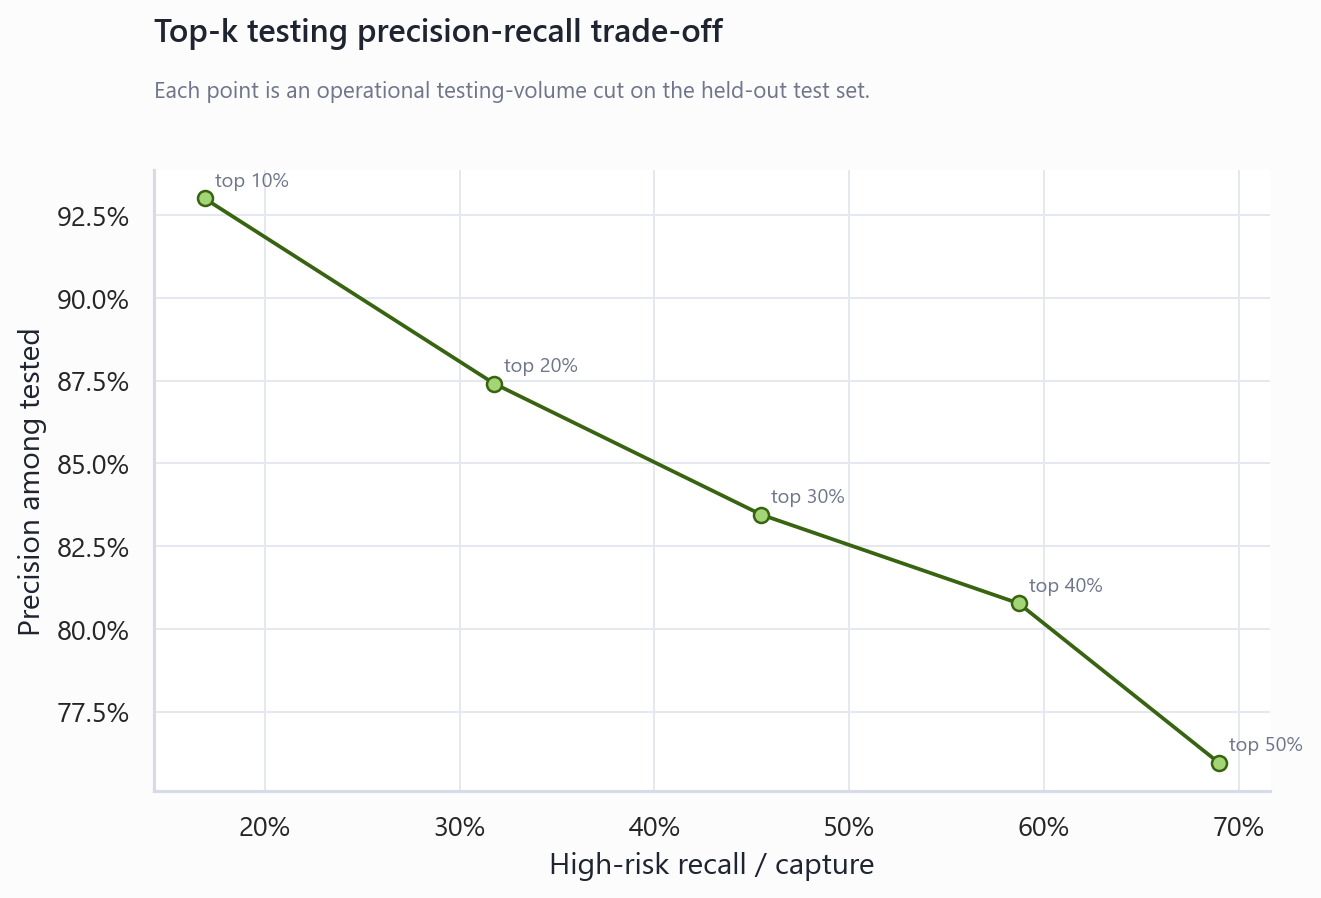

In [5]:
display(pd.read_csv(TABLES / 'topk_testing_simulation.csv').round(3))
display(pd.read_csv(TABLES / 'testing_burden_reduction.csv').round(3))
display(pd.read_csv(TABLES / 'acceptance_criteria.csv'))
display(Image(filename=str(FIGURES / 'high_risk_capture_curve.png')))
display(Image(filename=str(FIGURES / 'topk_precision_recall.png')))


## Final decision

In [6]:
display(Markdown((ROOT / 'reports' / 'nhanes_feasibility' / 'FEASIBILITY_SUMMARY.md').read_text(encoding='utf-8')))
display(Markdown((ROOT / 'reports' / 'nhanes_feasibility' / 'NHANES_PILOT_VERDICT.md').read_text(encoding='utf-8')))


# NHANES Feasibility Summary

## What problem we tested

We tested whether age, body measurements, blood pressure, medical history, lifestyle and access-to-care variables can help decide who should receive confirmatory glycemic testing first when testing capacity is limited.

## Why glycemic biomarkers were excluded from X

HbA1c, fasting glucose and OGTT glucose would make the prioritisation task circular. They were used only to define the outcome, never as model inputs. The model is a **pre-test ranking tool**, not a diabetes diagnosis.

## Was Tier-1 non-glycemic data enough?

**Decision: NO-GO — fall back to BRFSS.** The strongest evidence is the held-out testing simulation and the comparison against a transparent rule score. XGBoost's high-risk PR-AUC was **0.812**.

## How much testing burden could be reduced?

Testing the top 40% captured **58.7%** of high-risk participants and reduced immediate testing volume by **60.0%**. Reaching 80% high-risk capture required testing **60.9%** of participants, a **39.1%** reduction versus universal testing.

## Does the project have logical and business value?

The concept has value only if ranking meaningfully reduces immediate testing while retaining an acceptable share of high-risk cases. The acceptance criteria make that trade-off explicit and compare the boosted model with a simple operational rule.

## Final go/no-go decision

**NHANES Tier-1 pre-test prioritisation did not create enough incremental value. Recommended fallback: retain BRFSS as the official project and polish feature engineering, threshold tuning and reporting.**


# NHANES Pilot Verdict

## Technical summary

**Decision: NO-GO — fall back to BRFSS.**

This pilot tested whether quickly collectable, non-glycemic Tier-1 indicators can rank adults for confirmatory HbA1c, fasting-glucose or OGTT testing. It does **not** diagnose diabetes. Glycemic variables and self-reported diabetes status were used only to construct the ground-truth stage.

**Recommendation:** NHANES Tier-1 pre-test prioritisation did not create enough incremental value. Recommended fallback: retain BRFSS as the official project and polish feature engineering, threshold tuning and reporting.

## Dataset files used

| component | filename | status | source_url |
| --- | --- | --- | --- |
| demographics | DEMO_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DEMO_I.XPT |
| diabetes_questionnaire | DIQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DIQ_I.XPT |
| body_measures | BMX_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/BMX_I.XPT |
| blood_pressure_exam | BPX_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/BPX_I.XPT |
| blood_pressure_questionnaire | BPQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/BPQ_I.XPT |
| medical_conditions | MCQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/MCQ_I.XPT |
| physical_activity | PAQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/PAQ_I.XPT |
| smoking | SMQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/SMQ_I.XPT |
| alcohol | ALQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/ALQ_I.XPT |
| diet | DBQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DBQ_I.XPT |
| health_insurance | HIQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/HIQ_I.XPT |
| income | INQ_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/INQ_I.XPT |
| glycohemoglobin | GHB_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/GHB_I.XPT |
| fasting_glucose | GLU_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/GLU_I.XPT |
| ogtt | OGTT_I.XPT | available | https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/OGTT_I.XPT |

The analytical cohort contains **5,719 adults aged 20 years or older** after the one-row-per-participant merge and age restriction. NHANES complex survey weights were not used for model fitting; results describe this feasibility sample, not population prevalence.

## Target construction and label distribution

When label markers disagreed, the highest-risk class was assigned.

| label_source | nhanes_variable | available | class_1_rule | class_2_rule |
| --- | --- | --- | --- | --- |
| self-reported doctor-diagnosed/borderline diabetes | DIQ010 | True | DIQ010 == 3 (borderline) | DIQ010 == 1 (doctor diagnosed) |
| self-reported prediabetes | DIQ160 | True | DIQ160 == 1 (ever told prediabetes) | not used for class 2 |
| HbA1c | LBXGH | True | 5.7 <= LBXGH <= 6.4 | LBXGH >= 6.5 |
| fasting plasma glucose | LBXGLU | True | 100 <= LBXGLU <= 125 mg/dL | LBXGLU >= 126 mg/dL |
| 2-hour OGTT glucose | LBXGLT | True | 140 <= LBXGLT <= 199 mg/dL | LBXGLT >= 200 mg/dL |

| class | count | class_name | percentage |
| --- | --- | --- | --- |
| 0 | 2572 | Normal / lower-risk | 0.450 |
| 1 | 2017 | Diabetes-prone / prediabetes-risk | 0.353 |
| 2 | 1130 | Diabetic / diabetes-range | 0.198 |

![Label distribution](figures/label_distribution.png)

## Tier-1 features used

The main model used **65 available non-glycemic features**. Missing candidates were skipped rather than forced.

| feature | source_group | type | missing_pct |
| --- | --- | --- | --- |
| RIDAGEYR | demographics | numeric | 0.000 |
| RIAGENDR | demographics | categorical | 0.000 |
| RIDRETH3 | demographics | categorical | 0.000 |
| DMDEDUC2 | demographics | categorical | 0.000 |
| INDFMPIR | demographics | numeric | 0.111 |
| HIQ011 | demographics | categorical | 0.000 |
| BMXHT | anthropometrics | numeric | 0.053 |
| BMXWT | anthropometrics | numeric | 0.054 |
| BMXBMI | anthropometrics | numeric | 0.055 |
| BMXWAIST | anthropometrics | numeric | 0.105 |
| BPXSY1 | vitals | numeric | 0.099 |
| BPXSY2 | vitals | numeric | 0.077 |
| BPXSY3 | vitals | numeric | 0.081 |
| BPXSY4 | vitals | numeric | 0.958 |
| BPXDI1 | vitals | numeric | 0.099 |
| BPXDI2 | vitals | numeric | 0.077 |
| BPXDI3 | vitals | numeric | 0.081 |
| BPXDI4 | vitals | numeric | 0.958 |
| BPXPLS | vitals | numeric | 0.069 |
| BPQ020 | medical_history | categorical | 0.000 |
| BPQ080 | medical_history | categorical | 0.000 |
| BPQ040A | medical_history | categorical | 0.638 |
| BPQ090D | medical_history | categorical | 0.225 |
| MCQ160B | medical_history | categorical | 0.000 |
| MCQ160C | medical_history | categorical | 0.000 |
| MCQ160D | medical_history | categorical | 0.000 |
| MCQ160E | medical_history | categorical | 0.000 |
| MCQ160F | medical_history | categorical | 0.000 |
| SMQ020 | lifestyle | categorical | 0.000 |
| SMQ040 | lifestyle | categorical | 0.583 |
| PAQ605 | lifestyle | categorical | 0.000 |
| PAQ620 | lifestyle | categorical | 0.000 |
| PAQ650 | lifestyle | categorical | 0.000 |
| PAQ665 | lifestyle | categorical | 0.000 |
| PAD680 | lifestyle | numeric | 0.002 |
| ALQ101 | lifestyle | categorical | 0.133 |
| ALQ130 | lifestyle | numeric | 0.430 |
| ALQ141Q | lifestyle | numeric | 0.430 |
| ALQ141U | lifestyle | numeric | 0.776 |
| DBQ700 | lifestyle | categorical | 0.000 |
| DBD895 | lifestyle | numeric | 0.000 |
| DBD900 | lifestyle | numeric | 0.237 |
| DBD905 | lifestyle | numeric | 0.002 |
| DBD910 | lifestyle | numeric | 0.001 |
| INQ020 | socioeconomic_access | categorical | 0.035 |
| INQ012 | socioeconomic_access | categorical | 0.035 |
| bmi_category | engineered | categorical | 0.055 |
| waist_to_height_ratio | engineered | numeric | 0.106 |
| central_obesity_flag | engineered | numeric | 0.105 |
| age_band | engineered | categorical | 0.000 |
| bmi_x_age | engineered | numeric | 0.055 |
| bmi_x_waist | engineered | numeric | 0.107 |
| avg_systolic_bp | engineered | numeric | 0.071 |
| avg_diastolic_bp | engineered | numeric | 0.071 |
| pulse_pressure | engineered | numeric | 0.071 |
| mean_arterial_pressure | engineered | numeric | 0.071 |
| hypertension_flag | engineered | numeric | 0.000 |
| smoker_flag | engineered | numeric | 0.000 |
| physical_inactivity_flag | engineered | numeric | 0.000 |
| heavy_alcohol_flag | engineered | numeric | 0.430 |
| cholesterol_history_flag | engineered | numeric | 0.000 |
| cardiovascular_history_flag | engineered | numeric | 0.000 |
| cardiometabolic_history_count | engineered | numeric | 0.000 |
| low_income_access_risk_flag | engineered | numeric | 0.000 |
| insurance_gap_flag | engineered | numeric | 0.000 |

No clean, generally administered gestational-diabetes or PCOS history variable was identified in the selected 2015–2016 components, so no female-specific feature was forced into the model.

## Features excluded due to leakage

| variable_or_family | treatment |
| --- | --- |
| DIQ010 | Used only to construct the label |
| DIQ160 | Self-reported prediabetes; used only to construct the label |
| DIQ170 / DIQ172 | Diabetes-risk awareness/perception; excluded to avoid leakage |
| LBXGH | HbA1c; used only to construct the label |
| LBXGLU / LBDGLUSI | Fasting glucose and derivative; label-only/excluded |
| LBXGLT / LBDGLTSI | 2-hour OGTT glucose and derivative; label-only/excluded |
| HOMA-IR / TyG / glucose-derived features | Not constructed |

## Model comparison

| model | macro_f1 | class_0_recall | class_1_recall | class_2_recall | high_risk_recall | high_risk_precision | high_risk_pr_auc | high_risk_roc_auc | high_risk_brier_score |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| XGBoost | 0.549 | 0.635 | 0.409 | 0.671 | 0.793 | 0.726 | 0.812 | 0.788 | 0.191 |
| Logistic Regression | 0.546 | 0.641 | 0.399 | 0.668 | 0.785 | 0.728 | 0.807 | 0.785 | 0.194 |
| Simple Rule Score | 0.447 | 0.673 | 0.177 | 0.625 | 0.687 | 0.720 | 0.755 | 0.753 | 0.206 |

![XGBoost confusion matrix](figures/confusion_matrix_xgboost.png)

The business decision is based primarily on high-risk ranking quality and top-k capture, not on three-class accuracy alone.

## Top-k testing simulation

| model | testing_percentage | tested_n | testing_volume_reduction | high_risk_cases_captured | high_risk_capture_rate | diabetic_cases_captured | diabetic_capture_rate | diabetes_prone_cases_captured | diabetes_prone_capture_rate | number_needed_to_test | missed_high_risk_cases | precision_among_tested |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| XGBoost | 10.0% | 143 | 90.0% | 133 | 16.9% | 82 | 29.0% | 51 | 10.1% | 1.075 | 654 | 93.0% |
| XGBoost | 20.0% | 286 | 80.0% | 250 | 31.8% | 137 | 48.4% | 113 | 22.4% | 1.144 | 537 | 87.4% |
| XGBoost | 30.0% | 429 | 70.0% | 358 | 45.5% | 176 | 62.2% | 182 | 36.1% | 1.198 | 429 | 83.4% |
| XGBoost | 40.0% | 572 | 60.0% | 462 | 58.7% | 216 | 76.3% | 246 | 48.8% | 1.238 | 325 | 80.8% |
| XGBoost | 50.0% | 715 | 50.0% | 543 | 69.0% | 244 | 86.2% | 299 | 59.3% | 1.317 | 244 | 75.9% |

![High-risk capture curve](figures/high_risk_capture_curve.png)

![Top-k precision-recall](figures/topk_precision_recall.png)

## Testing required for target capture

| model | target_high_risk_recall | tested_n | minimum_testing_percentage | testing_volume_reduction | high_risk_cases_required |
| --- | --- | --- | --- | --- | --- |
| XGBoost | 70.0% | 731 | 51.1% | 48.9% | 551 |
| XGBoost | 80.0% | 871 | 60.9% | 39.1% | 630 |
| XGBoost | 90.0% | 1077 | 75.3% | 24.7% | 709 |

![Calibration curve](figures/calibration_curve.png)

## Acceptance criteria

Criterion C defines “materially beats” before inspecting results as at least +0.03 high-risk PR-AUC and +0.05 absolute high-risk capture at top 30% or top 40% versus the simple rule score.

| criterion | definition | observed | passed |
| --- | --- | --- | --- |
| A | Top 30% captures >=70% OR top 40% captures >=80% of high-risk cases | top30=45.5%; top40=58.7% | False |
| B | At 80% high-risk recall, testing volume is reduced by >=40% | testing=60.9%; reduction=39.1% | False |
| C | XGBoost exceeds rule score by >=0.03 PR-AUC and >=0.05 top-k capture | PR-AUC delta=+0.057; top30 delta=+2.2%; top40 delta=+3.2% | False |

## Final recommendation

**NHANES Tier-1 pre-test prioritisation did not create enough incremental value. Recommended fallback: retain BRFSS as the official project and polish feature engineering, threshold tuning and reporting.**

Do not position this pilot as the replacement project. Keep the BRFSS work as the official project and retain this NHANES pilot as documented negative feasibility evidence.

## Limitations and robustness notes

- This is a held-out feasibility result from one NHANES cycle, not external validation.
- NHANES is a complex survey; unweighted predictive evaluation does not estimate US prevalence.
- Some fasting/OGTT labels are structurally missing because those tests apply to examination subsamples.
- Class 0 means no available criterion met the class 1 or class 2 thresholds; it does not prove absence of dysglycemia.
- Operational value depends on local prevalence, testing costs, capacity and acceptable miss rates.
